### **Machine Learning for Data Analytics**
### **Assignment 1**
#### Piotr Czech, Filip Miśkiewicz

#### **Imports**

In [30]:
import time             # Used to track the exact duration of model training
import tracemalloc      # Used to measure the peak RAM consumption of our models
import warnings         # Used to suppress non-critical warnings that clutter the notebook
from typing import Dict, List, Tuple, Any # Used for strict Python type hinting (PEP 484)

import numpy as np      # Used for numerical operations and exponential/log transformations
import pandas as pd     # Used for loading, manipulating, and displaying data structures
import matplotlib.pyplot as plt  # Used for creating visualizations and plots
from IPython.display import display # Used to render Pandas DataFrames natively in Jupyter
from tqdm.auto import tqdm          # Used to generate progress bars for long loops
from sklearn.model_selection import KFold  # Used for splitting data properly
from sklearn.metrics import root_mean_squared_error  # Used for calculating the primary error metric
from sklearn.dummy import DummyRegressor #Used for a Naive Baseline

# models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

#optuna bayesian optimization
import optuna
from optuna.samplers import TPESampler, RandomSampler
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

In [35]:
# Suppress specific warnings (like LightGBM's categorical feature warnings) for a clean notebook UI
warnings.filterwarnings('ignore', category=UserWarning)
# Mute Optuna's experimental matplotlib warnings
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

#### **Task 2**

We will compare the performance of three machine learning models in predicting house prices based on the Kaggle House Prices Dataset.

First, we define a function to perform a preliminary analysis of the dataset, focusing on its shape, missing values, and the target column.

In [21]:
def perform_basic_eda(df: pd.DataFrame) -> None:
    """
    Performs Basic Exploratory Data Analysis (EDA) using native Pandas display.
    
    Args:
        df (pd.DataFrame): The loaded dataset.
    """
    print("1. Dataset Shape:", df.shape)
    
    print("\n2. First 5 Rows (Head):")
    # Native display creates a beautifully formatted HTML table in Jupyter
    display(df.head())
    
    print("\n3. Missing Values Summary (Top 10 columns):")
    # Count missing values, filter out columns with 0 missing, and sort descending
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    
    if missing_data.empty:
        print("No missing values found.")
    else:
        # Convert to DataFrame for pretty Jupyter rendering
        display(pd.DataFrame({'Missing Count': missing_data.head(10)}))
        
    print("\n4. Target Variable ('SalePrice') Summary:")
    if 'SalePrice' in df.columns:
        # Transpose the describe() output to make it easier to read horizontally
        display(pd.DataFrame(df['SalePrice'].describe()).T)
    else:
        print("Warning: 'SalePrice' column not found in the dataset.")

Now we want a tool that will load and preprocess the data, using the function we defined before.

In [22]:
def load_and_preprocess_data(filepath: str) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    """
    Loads the dataset, handles categorical missing values, and applies log transformation.
    
    Args:
        filepath (str): The local path to the house prices CSV file.
        
    Returns:
        X (pd.DataFrame): The feature matrix, safely copied and ready for training.
        y_log (pd.Series): The log-transformed target variable (SalePrice).
        cat_features (List[str]): A list of column names that contain categorical data.
    """
    # 1. Load the data from the provided CSV file
    df = pd.read_csv(filepath)
    
    # 2. Perform exploratory data analysis right after loading
    perform_basic_eda(df)
    
    # 3. Separate the target variable (what we want to predict) from the features
    y = df['SalePrice']
    # Use .copy() to ensure we create a distinct object in memory, avoiding SettingWithCopy warnings
    X = df.drop(columns=['SalePrice']).copy()
    
    # 4. Drop the 'Id' column. It is a unique identifier and holds no predictive value.
    if 'Id' in X.columns:
        X = X.drop(columns=['Id'])

    # 5. Log-transform the target. House prices are heavily right-skewed. 
    # Applying log(1+x) makes the distribution more normal, which helps trees learn better.
    y_log = np.log1p(y)

    # 6. Identify categorical features. Modern frameworks prefer pandas 'category' dtypes.
    cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
    
    for col in cat_features:
        # Fill missing categorical values with the string 'Missing'. 
        # This treats "missingness" as a valid category, which is often highly predictive.
        X[col] = X[col].fillna('Missing')
        # Convert the column dtype to 'category' so LightGBM and XGBoost recognize it natively
        X[col] = X[col].astype('category')
        
    # Note: We leave numerical missing values (NaNs) alone. 
    # XGBoost, LightGBM, and CatBoost all have native logic to route NaNs optimally during splits.
    return X, y_log, cat_features

After that, we define the function to evaluate each model, focusing on the accuracy, time needed to perform and memory used. We use cross-validation for more accurate results.

In [23]:
def evaluate_model(
    model_name: str, 
    model: Any, 
    X: pd.DataFrame, 
    y_log: pd.Series, 
    cat_features: List[str],
    n_splits: int = 5
) -> Tuple[Dict[str, List[float]], np.ndarray]:
    """
    Evaluates a model using K-Fold CV. Tracks time, memory, RMSE in actual dollars, 
    and captures Out-Of-Fold (OOF) predictions.
    
    Args:
        model_name (str): Name of the model for display purposes.
        model (Any): The initialized machine learning model.
        X (pd.DataFrame): Feature matrix.
        y_log (pd.Series): Log-transformed target variable.
        cat_features (List[str]): List of categorical columns.
        n_splits (int): Number of folds for cross-validation.
        
    Returns:
        Tuple: 
            - Dict: Lists of metrics (RMSE in dollars, time, memory) recorded across all folds.
            - np.ndarray: The complete Out-Of-Fold predictions for the entire dataset.
    """
    # Initialize the K-Fold splitter. Shuffle=True ensures random distribution of data.
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Dictionary to store the metrics for each fold
    metrics = {
        'rmse_dollars': [],
        'time_sec': [],
        'memory_mb': []
    }
    
    # Array to store Out-Of-Fold predictions. We initialize it with zeros matching the dataset length.
    oof_preds_log = np.zeros(len(X))
    
    # Wrap the KFold generator in tqdm to display a progress bar in the notebook
    for train_idx, val_idx in tqdm(kf.split(X), total=n_splits, desc=f"Training {model_name}"):
        
        # Split the data into training and validation sets for this specific fold
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        
        # Start tracking time and peak memory consumption
        start_time = time.perf_counter()
        tracemalloc.start()
        
        # Fit the model. CatBoost requires the categorical features to be explicitly passed.
        if model_name == 'CatBoost':
            model.fit(X_train, y_train_log, cat_features=cat_features, verbose=False)
        else:
            model.fit(X_train, y_train_log)
            
        # Stop tracking memory and time once fitting is complete
        _, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        end_time = time.perf_counter()
        
        # Predict on the validation set. These predictions are still in log scale.
        preds_log = model.predict(X_val)
        
        # Store these unbiased predictions in the exact indices they belong to
        oof_preds_log[val_idx] = preds_log
        
        # REVERT TRANSFORMATION: Apply exponential minus 1 to get back to original dollar values
        preds_dollar = np.expm1(preds_log)
        y_val_dollar = np.expm1(y_val_log)
        
        # Calculate standard RMSE on the dollar values for this specific fold
        rmse_dollar = root_mean_squared_error(y_val_dollar, preds_dollar)
        
        # Append the calculated metrics for this fold to our tracking dictionary
        metrics['rmse_dollars'].append(rmse_dollar)
        metrics['time_sec'].append(end_time - start_time)
        metrics['memory_mb'].append(peak_mem / (1024 * 1024)) # Convert bytes to Megabytes
        
    return metrics, oof_preds_log

We also define a function to visualize predictions of the models. We use Out Of Fold (OOF) approach which means that we take the predictions from the 1 unseen chunk in Fold 1, the unseen chunk in Fold 2, etc., and we stitch them all together. Because every row in the dataset was in the unseen validation chunk exactly once, we end up with one complete array of predictions for all 1,460 houses that we can show on the figure. 

In [24]:
def plot_oof_predictions(oof_predictions: Dict[str, np.ndarray], y_log: pd.Series) -> None:
    """
    Generates a scatter plot of True vs OOF Predicted values to visualize model performance.
    Automatically scales the number of subplots based on the number of models.
    
    Args:
        oof_predictions (Dict): Dictionary mapping model names to their OOF prediction arrays.
        y_log (pd.Series): Complete log-transformed true target.
    """
    # Revert true target back to dollars for the axes
    y_true_dollar = np.expm1(y_log)
    
    # Dynamically determine the number of models
    num_models = len(oof_predictions)
    
    # Initialize a dynamically sized figure (6 inches of width per model)
    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 6))
    fig.suptitle('Actual vs. OOF Predicted Sale Prices (Cross-Validated)', fontsize=16)
    
    # Handle the edge case where there is only 1 model (axes is not a list in this case)
    if num_models == 1:
        axes = [axes]
        
    for ax, (name, preds_log) in zip(axes, oof_predictions.items()):
        # Revert OOF predictions back to dollars
        preds_dollar = np.expm1(preds_log)
        
        # Plot the scatter points (True vs Predicted)
        ax.scatter(y_true_dollar, preds_dollar, alpha=0.5, color='steelblue', edgecolor='k', label="Model prediction")
        
        # Plot the perfect prediction diagonal line (y = x)
        max_val = max(y_true_dollar.max(), preds_dollar.max())
        min_val = min(y_true_dollar.min(), preds_dollar.min())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Prediction')
        
        # Format the axes and titles
        ax.set_title(f"{name} (OOF Results)")
        ax.set_xlabel('True Price ($)')
        ax.set_ylabel('Predicted Price ($)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

Now we can start analyzing our dataset. Let's load the data.

In [25]:
# Update this path if necessary to point to local dataset
data_path = "data/house_prices.csv"

# Load data and apply preprocessing (handling cat missing values, logging target)
X, y_log, cat_features = load_and_preprocess_data(data_path)

1. Dataset Shape: (1460, 81)

2. First 5 Rows (Head):


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



3. Missing Values Summary (Top 10 columns):


,Missing Count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81



4. Target Variable ('SalePrice') Summary:


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0


We can see that there are many missing values in the dataset, but we do not need to do anything extra. The models we use are able to perform correctly with the preprocessing we already provided. We can initialize the three frameworks.

In [26]:
# Define baseline hyperparameters to keep the comparison fair across algorithms
common_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'random_state': 42
}

# Initialize the three frameworks
models = {
    # always predicts the mean of the training target
    'Baseline (Mean)': DummyRegressor(strategy='mean'),

    # tree_method='hist' allows XGBoost to handle categorical data natively
    'XGBoost': XGBRegressor(**common_params, max_depth=6, tree_method='hist', enable_categorical=True),
    
    # num_leaves=63 is roughly equivalent to max_depth=6 for LightGBM's leaf-wise growth, 
    # setting verbosity to -1 is the strict command for "Fatal errors only",
    # deterministic=True to force LightGBM multi-threading to be strictly reproducible
    'LightGBM': LGBMRegressor(**common_params, max_depth=6, num_leaves=63, verbose=-1, deterministic=True),
    
    # allow_writing_files=False prevents clutter.
    'CatBoost': CatBoostRegressor(**common_params, depth=6, verbose=False, allow_writing_files=False)
}

all_metrics = {}
all_oof_preds = {}

print("\nStarting robust cross-validation evaluation (capturing OOF predictions)...")
# Iterate through models, evaluate them, and store both the metrics and the OOF predictions
for name, model in models.items():
    metrics, oof_preds = evaluate_model(name, model, X, y_log, cat_features, n_splits=5)
    all_metrics[name] = metrics
    all_oof_preds[name] = oof_preds

# Compile the tracked metrics into a list of dictionaries to create a clean Pandas DataFrame
results_list = []
for name, metrics in all_metrics.items():
    results_list.append({
        'Model': name,
        'Best RMSE ($)': np.min(metrics['rmse_dollars']),
        'Worst RMSE ($)': np.max(metrics['rmse_dollars']),
        'Avg RMSE ($)': np.mean(metrics['rmse_dollars']),
        'Best Time (s)': np.min(metrics['time_sec']),
        'Worst Time (s)': np.max(metrics['time_sec']),
        'Avg Time (s)': np.mean(metrics['time_sec']),
        'Avg Peak Mem (MB)': np.mean(metrics['memory_mb'])
    })

# Convert to DataFrame, set the model name as the index, and display natively in Jupyter
results_df = pd.DataFrame(results_list)
results_df.set_index('Model', inplace=True)


Starting robust cross-validation evaluation (capturing OOF predictions)...


Training Baseline (Mean):   0%|          | 0/5 [00:00<?, ?it/s]

Training XGBoost:   0%|          | 0/5 [00:00<?, ?it/s]

Training LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

Training CatBoost:   0%|          | 0/5 [00:00<?, ?it/s]

Now we can compare the results.

In [27]:
print("\nFinal Model Comparison (Original Dollar Scale):")
# Use native display and round the results for clean readability
display(results_df.round(2)) 


Final Model Comparison (Original Dollar Scale):


,Best RMSE ($),Worst RMSE ($),Avg RMSE ($),Best Time (s),Worst Time (s),Avg Time (s),Avg Peak Mem (MB)
Model,,,,,,,
Baseline (Mean),73620.74,88270.85,80513.07,0.00,0.00,0.00,0.00
XGBoost,24622.25,38724.06,30350.87,2.38,2.49,2.46,0.57
LightGBM,21655.54,37585.63,28389.59,0.56,0.61,0.59,4.95
CatBoost,19287.68,42777.60,27907.58,36.36,45.76,38.54,0.16


We can see that all the advanced models provided similar level of accuracy, absolutely outscoring the naive baseline. The best one in terms of average RMSE across all folds is CatBoost. We need to mention that it was also significantly slower than XGBoost and LightGBM. Before choosing CatBoost on this particular dataset, we recommend to consider whether the difference in accuracy is worth the time needed for it to work. On average, LightGBM required much more memory than the two other models, but we do not find its memory usage especially concerning.

At the end we can plot the results using OOF predictions to visually compare the models.


Generating rigorous OOF prediction performance plots...


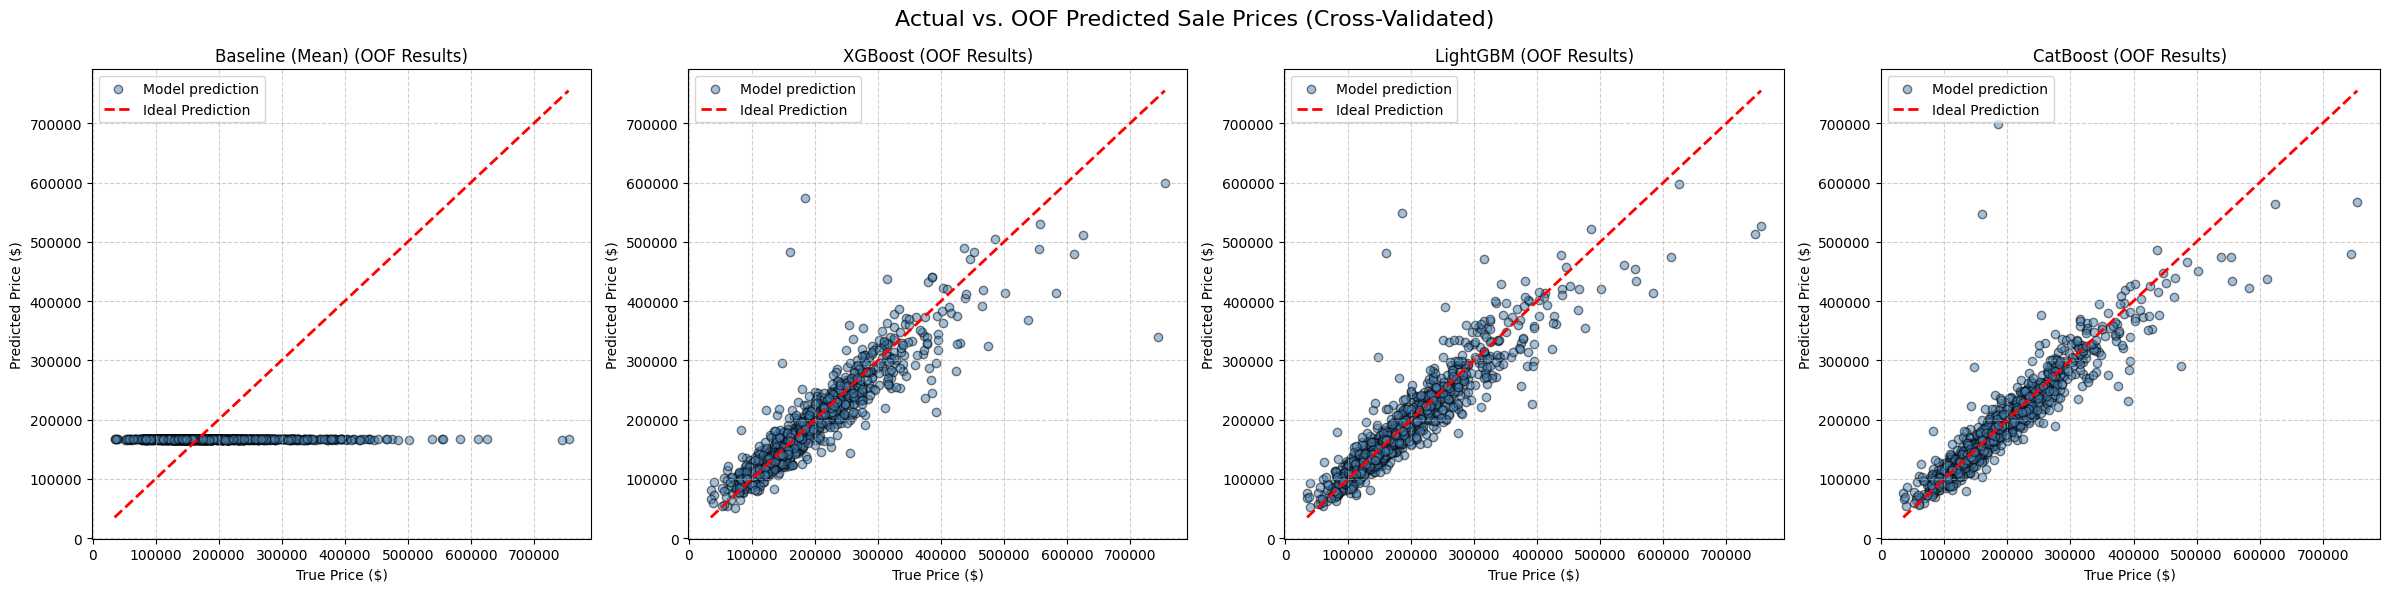

In [28]:
# Generate the visual performance plots using the unbiased OOF predictions
print("\nGenerating rigorous OOF prediction performance plots...")
plot_oof_predictions(all_oof_preds, y_log)

We can see that all models performed relatively well in predicting the overall trend. Each of them proved to be more accurate for low to medium priced homes, while the largest errors occurred with very high-priced luxury homes, where the models conistently underestimated their true value. 

#### **Task 4**

We will utilize Optuna for Bayesian Optimization of XGBoost hyperparameters.

There are 7 key hyperparameters to optimize:
1. `learning_rate`: Step size shrinkage used to prevent overfitting.
2. `max_depth`: Maximum depth of a tree.
3. `subsample`: Subsample ratio of the training instances.
4. `colsample_bytree`: Subsample ratio of columns when constructing each tree.
5. `min_child_weight`: Minimum sum of instance weight needed in a child.
6. `reg_alpha`: L1 regularization term on weights.
7. `reg_lambda`: L2 regularization term on weights.
We will run two separate studies of 100 trials each. The first will use Optuna's default Tree-structured Parzen Estimator (TPE) which mathematically learns from previous trials. The second will use a pure Random Sampler as a baseline comparison. Finally, we will visualize the optimization history and analyze which hyperparameters had the biggest impact on our model's performance.

In [32]:
# Set optuna verbosity to WARNING to avoid printing 200 lines of text to the notebook
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, X: pd.DataFrame, y_log: pd.Series, cv_splits: int = 5) -> float:
    """
    Optuna objective function for tuning XGBoost.
    Evaluates a set of hyperparameters using K-Fold CV and returns the average Dollar RMSE.
    """
    # 1. Define the hyperparameter search space (7 parameters)
    param = {
        'n_estimators': 500, # Fixed to a reasonable number to keep runtime manageable
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        
        # Static parameters
        'tree_method': 'hist',
        'enable_categorical': True,
        'random_state': 42,
        'n_jobs': -1 # Use all available CPU cores
    }
    
    # 2. Initialize the model with the suggested parameters
    model = XGBRegressor(**param)
    
    # 3. Perform Cross-Validation
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    rmse_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        
        model.fit(X_train, y_train_log)
        preds_log = model.predict(X_val)
        
        # Convert back to dollars for the metric
        preds_dollar = np.expm1(preds_log)
        y_val_dollar = np.expm1(y_val_log)
        
        fold_rmse = root_mean_squared_error(y_val_dollar, preds_dollar)
        rmse_scores.append(fold_rmse)
        
    # We want Optuna to minimize the average RMSE across the folds
    return np.mean(rmse_scores)

In [33]:
# Study 1: Smart TPE Search (Optuna's Default)
tpe_sampler = TPESampler(seed=42)
study_tpe = optuna.create_study(direction='minimize', sampler=tpe_sampler)
# Wrapping the optimization in tqdm for a clean progress bar
for _ in tqdm(range(100), desc="TPE Optimization"):
    study_tpe.optimize(lambda trial: objective(trial, X, y_log), n_trials=1)

# Study 2: Blind Random Search (Baseline Comparison)
random_sampler = RandomSampler(seed=42)
study_random = optuna.create_study(direction='minimize', sampler=random_sampler)
for _ in tqdm(range(100), desc="Random Optimization"):
    study_random.optimize(lambda trial: objective(trial, X, y_log), n_trials=1)

TPE Optimization:   0%|          | 0/100 [00:00<?, ?it/s]

Random Optimization:   0%|          | 0/100 [00:00<?, ?it/s]

In [38]:
print("Optimization Results:")
print(f"Best RMSE (Random Search): ${study_random.best_value:,.2f}")
print(f"Best RMSE (TPE Search):    ${study_tpe.best_value:,.2f}")
print("Best XGBoost Hyperparameters (from TPE):")
display(pd.DataFrame([study_tpe.best_params]))

Optimization Results:
Best RMSE (Random Search): $26,089.72
Best RMSE (TPE Search):    $25,517.74
Best XGBoost Hyperparameters (from TPE):


,learning_rate,max_depth,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda
0,0.016719,6,0.747151,0.593765,10,1.739807e-07,0.198723


While the TPE algorithm took more computational time than the Random Search, there is a meaningful difference in the final RMSE values achieved. The TPE approach successfully outperformed the classical Random Search by over $500. This represents roughly a 2% relative improvement in the model's error rate, proving that TPE's ability to learn from previous trials yields a measurably more accurate model than blind guessing.

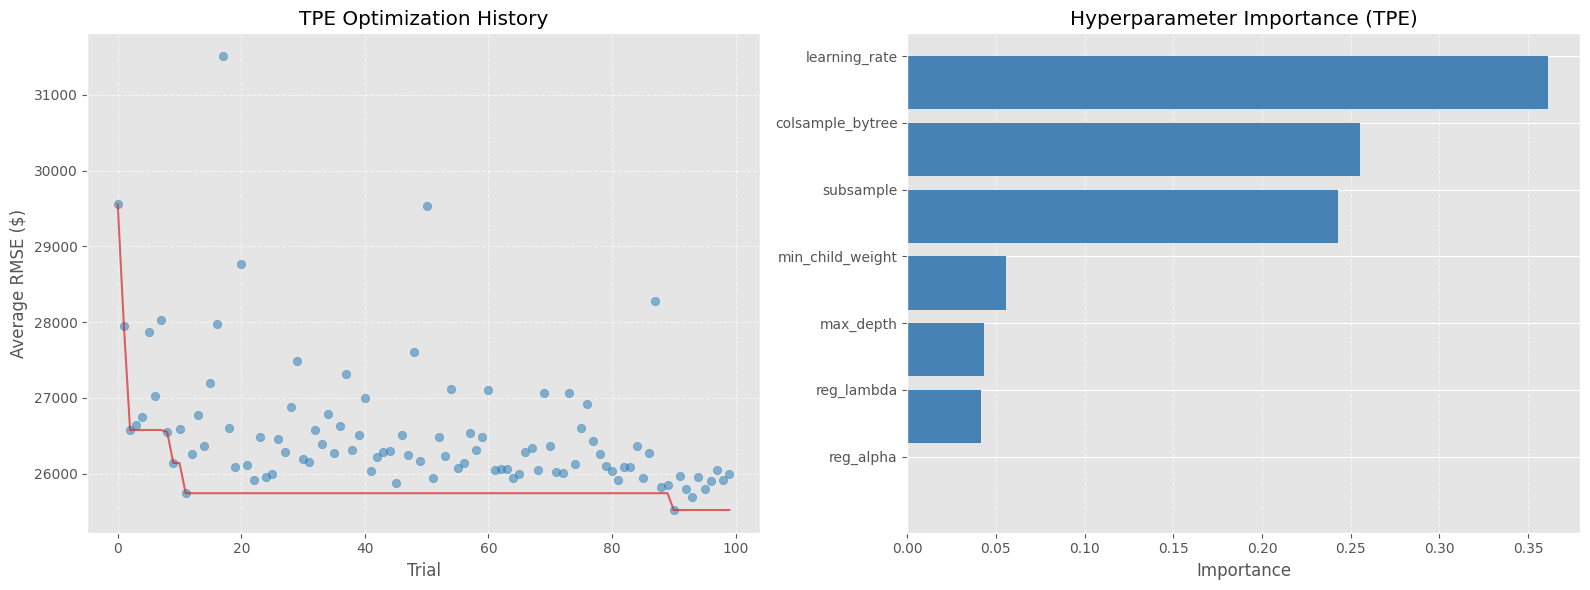

In [39]:
# Create static Matplotlib visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Optimization History (Comparing TPE)
plot_optimization_history(study_tpe)
# We have to grab the current figure from Optuna's matplotlib wrapper to format it in our subplots
fig1 = plt.gcf()
axes[0].clear()
for ax in fig1.axes:
    for line in ax.lines:
        axes[0].plot(line.get_xdata(), line.get_ydata(), marker=line.get_marker(), 
                     linestyle=line.get_linestyle(), color=line.get_color(), alpha=0.7)
    for collection in ax.collections:
        axes[0].scatter(collection.get_offsets()[:,0], collection.get_offsets()[:,1], 
                        color=collection.get_facecolor(), alpha=0.5, label='Objective Value')
plt.close(fig1)
axes[0].set_title("TPE Optimization History")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Average RMSE ($)")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Hyperparameter Importance
plot_param_importances(study_tpe)
fig2 = plt.gcf()
axes[1].clear()
for ax in fig2.axes:
    for container in ax.containers:
        axes[1].barh([rect.get_y() for rect in container], 
                     [rect.get_width() for rect in container], 
                     height=[rect.get_height() for rect in container], color='steelblue')
    axes[1].set_yticks(ax.get_yticks())
    axes[1].set_yticklabels([t.get_text() for t in ax.get_yticklabels()])
plt.close(fig2)
axes[1].set_title("Hyperparameter Importance (TPE)")
axes[1].set_xlabel("Importance")
axes[1].grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The red line on the TPE Optimization History plot indicates the best objective value achieved so far (the lowest RMSE). As the trials progress, we can see that the TPE algorithm actively learns from previous iterations, generally achieving better results in later trials compared to early ones. For this specific run, the 90th trial yielded the most accurate model. Furthermore, the Hyperparameter Importance plot (on the right) reveals that `learning_rate`, `colsample_bytree`, and `subsample` are the most critical parameters. Together, they account for approximately 88% of the model's performance variance, highlighting how crucial step-size and data subsampling are for optimizing XGBoost accuracy.